# Delays

This notebook estimates overall and stage-specific first-delay hazards with the model architecture used for Figure 2.

The analysis reads `cloglog_data_processed.rds`, uses the upstream transformations and standardisation, applies the Figure 2 core, end-use, macro, and waterfall controls, treats `region` as a factor with a reference category, and uses complementary log-log models with project-clustered inference and 90% confidence intervals. `prev_time_in_status` enters every delay model. The pooled main model omits project-stage indicators, while Supplementary Figure S7 uses three separately estimated models, one for each project stage.

`first_delay_event` identifies the first observed upward revision in scheduled completion and defines an absorbing first-delay risk set.

The country/macro specification uses the governance control selected in the master pipeline: `Governance_Score`, `Ease_of_doing_business`, or no additional governance control.


In [1]:
# Use the same project/data directory in standalone and master-run execution.
# With H2_PROJECT_DIR unset, run from the folder containing Data/ and the RDS files.
project_dir <- Sys.getenv("H2_PROJECT_DIR", unset = getwd())
project_dir <- normalizePath(project_dir, winslash = "/", mustWork = TRUE)
setwd(project_dir)

# The master pipeline passes this setting to each model notebook.
# Standalone execution defaults to Governance_Score.
governance_control <- Sys.getenv(
  "H2_GOVERNANCE_CONTROL",
  unset = "Governance_Score"
)

valid_governance_controls <- c(
  "Governance_Score",
  "Ease_of_doing_business",
  "none"
)

if (!governance_control %in% valid_governance_controls) {
  stop(
    paste0(
      "governance_control must be one of: ",
      paste(valid_governance_controls, collapse = ", ")
    )
  )
}


In [2]:
# ==============================================================================
# Packages and analysis configuration
# ==============================================================================

library(dplyr)
library(tidyr)
library(sandwich)
library(lmtest)
library(pROC)
library(purrr)
library(ggplot2)
library(ggsci)
library(scales)
library(patchwork)


# ------------------------------------------------------------------------------
# Input and estimation options
# ------------------------------------------------------------------------------

data_path <- "cloglog_data_processed.rds"

# This matches Figure 2: every waterfall specification for a given outcome is
# estimated on the complete-case sample required by the largest specification.
use_common_sample <- TRUE

# Figure 2 specifications used to construct the coefficient charts.
main_model_to_plot <- "Core + macro controls + year FE"
any_enduse_model_to_plot <- "Core + macro controls + year FE + any enduse"


# ------------------------------------------------------------------------------
# Load the Figure 2 model dataset
# ------------------------------------------------------------------------------

if (!file.exists(data_path)) {
  stop(
    paste0(
      "The Figure 2 input file was not found: ",
      data_path
    )
  )
}

cloglog_data <- readRDS(data_path)

required_input_variables <- c(
  "reference",
  "year",
  "delay",
  "prev_state",
  "prev_time_in_status",
  "cap.mwel_log",
  "Country_Risk_Spread_log",
  "RISE",
  "region",
  "any_enduse"
)

missing_input_variables <- setdiff(
  required_input_variables,
  names(cloglog_data)
)

if (length(missing_input_variables) > 0) {
  stop(
    paste0(
      "cloglog_data_processed.rds is missing required variables: ",
      paste(
        missing_input_variables,
        collapse = ", "
      )
    )
  )
}


Warning message:
“package ‘dplyr’ was built under R version 4.5.3”



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Loading required package: zoo



...

The following objects are masked from ‘package:stats’:

    cov, smooth, var




Warning message:
“package ‘purrr’ was built under R version 4.5.3”


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”



Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




In [3]:
# ==============================================================================
# Prepared Figure 2 input and first-delay risk set
# ==============================================================================


# ------------------------------------------------------------------------------
# Reuse the model-ready transformations created by Data Preparation
# ------------------------------------------------------------------------------
#
# cap.mwel_log, prev_time_in_status (time in stage), the macro controls, region coding, and
# any_enduse are already prepared in cloglog_data_processed.rds. Reapplying the
# transformations here would make the delay models depend on a second,
# notebook-specific preprocessing pass.

# ------------------------------------------------------------------------------
# Standardise indexing and event variables
# ------------------------------------------------------------------------------

cloglog_data <- cloglog_data %>%
  dplyr::mutate(
    .original_row = dplyr::row_number(),
    year_numeric = suppressWarnings(
      as.numeric(
        as.character(year)
      )
    ),
    prev_state_numeric = suppressWarnings(
      as.integer(
        as.character(prev_state)
      )
    ),
    .delay_text = tolower(
      trimws(
        as.character(delay)
      )
    ),
    delay_binary = dplyr::case_when(
      is.na(delay) ~ NA_integer_,
      .delay_text %in% c("0", "false", "f") ~ 0L,
      .delay_text %in% c("1", "true", "t") ~ 1L,
      TRUE ~ NA_integer_
    )
  )

invalid_delay_values <- cloglog_data %>%
  dplyr::filter(
    !is.na(delay),
    is.na(delay_binary)
  ) %>%
  dplyr::distinct(delay)

if (nrow(invalid_delay_values) > 0) {
  stop(
    paste0(
      "The delay variable contains values other than 0/1 or FALSE/TRUE: ",
      paste(
        invalid_delay_values$delay,
        collapse = ", "
      )
    )
  )
}

if (any(is.na(cloglog_data$reference))) {
  stop("Project identifiers in reference must not be missing.")
}

if (any(is.na(cloglog_data$year_numeric))) {
  stop("Every project-year must have a numeric year.")
}

if (any(is.na(cloglog_data$prev_state_numeric))) {
  stop("prev_state must be convertible to integer stage codes.")
}


# ------------------------------------------------------------------------------
# Check project-year uniqueness
# ------------------------------------------------------------------------------

duplicate_project_years <- cloglog_data %>%
  dplyr::count(
    reference,
    year_numeric,
    name = "n_rows"
  ) %>%
  dplyr::filter(
    n_rows > 1
  )

if (nrow(duplicate_project_years) > 0) {
  warning(
    paste0(
      nrow(duplicate_project_years),
      " project-year combinations contain multiple rows. ",
      "The original row order will break ties within a year."
    )
  )
}


# ------------------------------------------------------------------------------
# Identify first entry into delay
# ------------------------------------------------------------------------------
#
# The risk set includes the first-delay event row and excludes later
# observations, producing at most one first-delay event per project.

cloglog_data <- cloglog_data %>%
  dplyr::group_by(reference) %>%
  dplyr::arrange(
    year_numeric,
    .original_row,
    .by_group = TRUE
  ) %>%
  dplyr::mutate(
    delay_seen_through_year = cummax(
      tidyr::replace_na(
        delay_binary,
        0L
      )
    ),
    delay_seen_before_year = dplyr::lag(
      delay_seen_through_year,
      default = 0L
    ),
    first_delay_event = dplyr::case_when(
      delay_seen_before_year == 0L & delay_binary == 1L ~ 1L,
      is.na(delay_binary) ~ NA_integer_,
      TRUE ~ 0L
    ),
    at_risk_for_first_delay = delay_seen_before_year == 0L
  ) %>%
  dplyr::ungroup() %>%
  dplyr::filter(
    at_risk_for_first_delay,
    prev_state_numeric %in% c(1L, 2L, 3L)
  ) %>%
  dplyr::select(
    -.delay_text
  )


# ------------------------------------------------------------------------------
# Validate and summarise the risk set
# ------------------------------------------------------------------------------

delay_events_per_project <- cloglog_data %>%
  dplyr::group_by(reference) %>%
  dplyr::summarise(
    n_first_delay_events = sum(
      first_delay_event == 1L,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

if (any(delay_events_per_project$n_first_delay_events > 1L)) {
  stop("The risk set contains more than one first-delay event per project.")
}

delay_risk_summary <- dplyr::bind_rows(
  cloglog_data %>%
    dplyr::summarise(
      analysis = "Overall",
      project_years = dplyr::n(),
      projects = dplyr::n_distinct(reference),
      first_delay_events = sum(
        first_delay_event == 1L,
        na.rm = TRUE
      )
    ),
  cloglog_data %>%
    dplyr::mutate(
      analysis = dplyr::case_when(
        prev_state_numeric == 1L ~ "Concept",
        prev_state_numeric == 2L ~ "Feasibility stage",
        prev_state_numeric == 3L ~ "FID/construction",
        TRUE ~ NA_character_
      )
    ) %>%
    dplyr::group_by(analysis) %>%
    dplyr::summarise(
      project_years = dplyr::n(),
      projects = dplyr::n_distinct(reference),
      first_delay_events = sum(
        first_delay_event == 1L,
        na.rm = TRUE
      ),
      .groups = "drop"
    )
)

print(
  delay_risk_summary,
  row.names = FALSE
)


# A tibble: 4 × 4
  analysis          project_years projects first_delay_events
  <chr>                     <int>    <int>              <int>
1 Overall                    4273     2002                600
2 Concept                    1942      888                127
3 FID/construction            431      284                140
4 Feasibility stage          1900      937                333


In [4]:
# ==============================================================================
# Figure 2 model controls
# ==============================================================================
#
# These definitions are intentionally identical to Figure 2 and occur only once
# in this notebook. All overall and stage-specific delay models use them.


# ------------------------------------------------------------------------------
# End-use controls
# ------------------------------------------------------------------------------

enduse_controls_grouped <- c(
  "enduse_industrial",
  "enduse_transport",
  "enduse_chemicals",
  "enduse_power",
  "enduse_other"
)

enduse_controls_grouped <- enduse_controls_grouped[
  enduse_controls_grouped %in% names(cloglog_data)
]


# ------------------------------------------------------------------------------
# Core project-level controls
# ------------------------------------------------------------------------------

core_controls <- c(
  "cap.mwel_log",
  "prev_time_in_status",
  "technology",
  "electricity_source"
)


# ------------------------------------------------------------------------------
# Country- and region-level macro controls
# ------------------------------------------------------------------------------

governance_controls <- if (identical(governance_control, "none")) {
  character(0)
} else {
  governance_control
}

if (
  length(governance_controls) > 0L &&
  !governance_control %in% names(cloglog_data)
) {
  stop(
    paste0(
      "The selected governance control '",
      governance_control,
      "' is not available in cloglog_data_processed.rds."
    )
  )
}

macro_controls <- c(
  "Country_Risk_Spread_log",
  "RISE",
  "region",
  governance_controls
)


# ------------------------------------------------------------------------------
# Select controls present in the Figure 2 model dataset
# ------------------------------------------------------------------------------

core_controls <- core_controls[
  core_controls %in% names(cloglog_data)
]

macro_controls <- macro_controls[
  macro_controls %in% names(cloglog_data)
]


# ------------------------------------------------------------------------------
# Figure 2 waterfall sequence
# ------------------------------------------------------------------------------

waterfall_control_steps <- list(
  "Core variables" = core_controls,

  "Core + macro controls" = c(
    core_controls,
    enduse_controls_grouped,
    macro_controls
  ),

  "Core + macro controls + year FE" = c(
    core_controls,
    enduse_controls_grouped,
    macro_controls,
    "factor(year)"
  ),

  "Core + macro controls + year FE + any enduse" = c(
    core_controls,
    macro_controls,
    "factor(year)",
    "any_enduse"
  )
)


## Model-estimation helpers

The helper functions below construct complete-case samples, estimate complementary log-log models, calculate project-clustered inference, extract coefficients, and assemble diagnostics.


In [5]:
# ==============================================================================
# Formula and sample-construction helpers
# ==============================================================================


# ------------------------------------------------------------------------------
# Safely format variable names for model formulas
# ------------------------------------------------------------------------------

safe_term <- function(x) {
  # Keep formula expressions such as factor(year) and
  # factor(prev_state_numeric) unquoted.
  if (grepl("^factor\\(.+\\)$", x)) {
    return(x)
  }

  paste0(
    "`",
    x,
    "`"
  )
}


# ------------------------------------------------------------------------------
# Construct a complete-case model dataset
# ------------------------------------------------------------------------------

make_complete_model_data <- function(
    data,
    outcome,
    controls
) {
  # Convert factor(variable) formula expressions back to their underlying
  # column names for complete-case sample construction.
  raw_controls <- gsub(
    "^factor\\((.+)\\)$",
    "\\1",
    controls
  )

  raw_controls <- gsub(
    "`",
    "",
    raw_controls
  )

  model_vars <- unique(
    c(
      "reference",
      "year",
      outcome,
      raw_controls
    )
  )

  model_vars <- model_vars[
    model_vars %in% names(data)
  ]

  data %>%
    dplyr::select(
      dplyr::all_of(model_vars)
    ) %>%
    tidyr::drop_na()
}


# ==============================================================================
# Clustered inference helper
# ==============================================================================


# ------------------------------------------------------------------------------
# Calculate project-clustered inference and retain diagnostic information
# ------------------------------------------------------------------------------

calculate_clustered_inference <- function(
    model,
    model_data
) {
  inference_warnings <- character()
  inference_error <- NA_character_

  inference_result <- tryCatch(
    withCallingHandlers(
      {
        vcov_mat <- sandwich::vcovCL(
          model,
          cluster = model_data$reference
        )

        coefficient_test <- lmtest::coeftest(
          model,
          vcov. = vcov_mat
        )

        list(
          vcov_mat = vcov_mat,
          coefficient_test = coefficient_test
        )
      },
      warning = function(w) {
        inference_warnings <<- c(
          inference_warnings,
          conditionMessage(w)
        )

        invokeRestart("muffleWarning")
      }
    ),
    error = function(e) {
      inference_error <<- conditionMessage(e)
      NULL
    }
  )

  if (is.null(inference_result)) {
    return(
      list(
        vcov_mat = NULL,
        coefficient_test = NULL,
        inference_warnings = unique(inference_warnings),
        inference_error = inference_error,
        invalid_variance_terms = character(),
        invalid_inference_terms = character()
      )
    )
  }

  variance_diagonal <- diag(
    inference_result$vcov_mat
  )

  invalid_variance_terms <- names(variance_diagonal)[
    !is.finite(variance_diagonal) |
      variance_diagonal < 0
  ]

  coefficient_matrix <- as.matrix(
    inference_result$coefficient_test
  )

  invalid_inference_rows <- !is.finite(
    coefficient_matrix[, 2]
  ) |
    !is.finite(
      coefficient_matrix[, ncol(coefficient_matrix)]
    )

  invalid_inference_terms <- rownames(coefficient_matrix)[
    invalid_inference_rows
  ]

  list(
    vcov_mat = inference_result$vcov_mat,
    coefficient_test = inference_result$coefficient_test,
    inference_warnings = unique(inference_warnings),
    inference_error = inference_error,
    invalid_variance_terms = invalid_variance_terms,
    invalid_inference_terms = invalid_inference_terms
  )
}


# ==============================================================================
# Model estimation
# ==============================================================================


# ------------------------------------------------------------------------------
# Estimate a complementary log-log model
# ------------------------------------------------------------------------------

run_standard_cloglog <- function(
    data,
    outcome,
    controls
) {
  controls <- controls[
    controls == "factor(year)" |
      gsub("`", "", controls) %in% names(data)
  ]

  cleaned_controls <- gsub(
    "`",
    "",
    controls
  )

  include_year_fe <- "factor(year)" %in% controls

  model_data <- make_complete_model_data(
    data = data,
    outcome = outcome,
    controls = controls
  )

  if (nrow(model_data) == 0) {
    return(NULL)
  }

  if (!outcome %in% names(model_data)) {
    return(NULL)
  }

  if (dplyr::n_distinct(model_data[[outcome]]) < 2) {
    return(NULL)
  }

  # Use Other as the technology reference category so the displayed
  # treatment-coded coefficients are Alkaline vs Other and PEM vs Other.
  if (
    "technology" %in% cleaned_controls &&
      "technology" %in% names(model_data)
  ) {
    if (!"Other" %in% as.character(model_data$technology)) {
      stop("Technology reference category 'Other' is absent from the model sample.")
    }

    model_data <- model_data %>%
      dplyr::mutate(
        technology = stats::relevel(
          factor(technology),
          ref = "Other"
        )
      )
  }

  # Match the capacity-curve notebook by treating region as an ordinary factor.
  if (
    "region" %in% cleaned_controls &&
      "region" %in% names(model_data)
  ) {
    model_data <- model_data %>%
      dplyr::mutate(
        region = factor(region)
      )
  }

  reference_year <- if (include_year_fe) {
    as.character(
      levels(
        factor(model_data$year)
      )[1]
    )
  } else {
    NA_character_
  }

  reference_region <- if (
    "region" %in% cleaned_controls &&
      "region" %in% names(model_data)
  ) {
    as.character(
      levels(model_data$region)[1]
    )
  } else {
    NA_character_
  }

  formula_terms <- vapply(
    controls,
    safe_term,
    character(1)
  )

  formula_rhs <- if (length(formula_terms) == 0) {
    "1"
  } else {
    paste(
      formula_terms,
      collapse = " + "
    )
  }

  model_formula <- stats::as.formula(
    paste(
      safe_term(outcome),
      "~",
      formula_rhs
    )
  )


  fit_warnings <- character()
  fit_error <- NA_character_

  model <- tryCatch(
    withCallingHandlers(
      stats::glm(
        formula = model_formula,
        data = model_data,
        family = stats::binomial(
          link = "cloglog"
        )
      ),
      warning = function(w) {
        fit_warnings <<- c(
          fit_warnings,
          conditionMessage(w)
        )

        invokeRestart("muffleWarning")
      }
    ),
    error = function(e) {
      fit_error <<- conditionMessage(e)
      NULL
    }
  )

  if (is.null(model)) {
    return(
      list(
        model = NULL,
        data = model_data,
        reference_year = reference_year,
        reference_region = reference_region,
        fit_warnings = unique(fit_warnings),
        fit_error = fit_error,
        converged = FALSE,
        boundary_probability_count = NA_integer_,
        aliased_coefficients = character(),
        extreme_coefficient_terms = character(),
        vcov_mat = NULL,
        coefficient_test = NULL,
        inference_warnings = character(),
        inference_error = NA_character_,
        invalid_variance_terms = character(),
        invalid_inference_terms = character()
      )
    )
  }

  fitted_probabilities <- stats::fitted(
    model
  )

  probability_tolerance <- 10 * .Machine$double.eps

  boundary_probability_count <- sum(
    !is.finite(fitted_probabilities) |
      fitted_probabilities <= probability_tolerance |
      fitted_probabilities >= 1 - probability_tolerance,
    na.rm = TRUE
  )

  coefficient_values <- stats::coef(
    model
  )

  aliased_coefficients <- names(coefficient_values)[
    is.na(coefficient_values)
  ]

  extreme_coefficient_terms <- names(coefficient_values)[
    is.finite(coefficient_values) &
      abs(coefficient_values) > 50
  ]

  clustered_inference <- calculate_clustered_inference(
    model = model,
    model_data = model_data
  )

  list(
    model = model,
    data = model_data,
    reference_year = reference_year,
    reference_region = reference_region,
    fit_warnings = unique(fit_warnings),
    fit_error = fit_error,
    converged = isTRUE(model$converged),
    boundary_probability_count = boundary_probability_count,
    aliased_coefficients = aliased_coefficients,
    extreme_coefficient_terms = extreme_coefficient_terms,
    vcov_mat = clustered_inference$vcov_mat,
    coefficient_test = clustered_inference$coefficient_test,
    inference_warnings = clustered_inference$inference_warnings,
    inference_error = clustered_inference$inference_error,
    invalid_variance_terms = clustered_inference$invalid_variance_terms,
    invalid_inference_terms = clustered_inference$invalid_inference_terms
  )
}


# ==============================================================================
# Coefficient extraction
# ==============================================================================


# ------------------------------------------------------------------------------
# Extract coefficients with project-clustered standard errors
# ------------------------------------------------------------------------------

extract_standard_cloglog <- function(
    model_obj,
    model_name
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$coefficient_test)
  ) {
    output <- data.frame(
      variable = character(),
      stringsAsFactors = FALSE
    )

    output[[model_name]] <- character()

    return(output)
  }

  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  output <- data.frame(
    variable = rownames(coefficient_matrix),
    estimate = as.numeric(
      coefficient_matrix[, 1]
    ),
    p.value = as.numeric(
      coefficient_matrix[, ncol(coefficient_matrix)]
    ),
    stringsAsFactors = FALSE
  ) %>%
    dplyr::filter(
      variable != "(Intercept)"
    ) %>%
    dplyr::filter(
      !grepl(
        "^factor\\(year\\)",
        variable
      )
    ) %>%
    dplyr::mutate(
      significance = dplyr::case_when(
        !is.na(p.value) & p.value < 0.001 ~ "***",
        !is.na(p.value) & p.value < 0.01 ~ "**",
        !is.na(p.value) & p.value < 0.05 ~ "*",
        !is.na(p.value) & p.value < 0.10 ~ "+",
        TRUE ~ ""
      ),
      coefficient = paste0(
        sprintf(
          "%.4f",
          estimate
        ),
        significance
      )
    ) %>%
    dplyr::select(
      variable,
      coefficient
    )

  names(output)[
    names(output) == "coefficient"
  ] <- model_name

  output
}


# ==============================================================================
# Model performance and descriptive statistics
# ==============================================================================

calc_auc <- function(
    model_obj,
    outcome
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  predicted_probability <- stats::predict(
    model_obj$model,
    newdata = model_obj$data,
    type = "response"
  )

  actual_outcome <- model_obj$data[[outcome]]

  valid_rows <- !is.na(predicted_probability) &
    !is.na(actual_outcome)

  if (
    sum(valid_rows) == 0 ||
      dplyr::n_distinct(actual_outcome[valid_rows]) < 2
  ) {
    return(NA_real_)
  }

  roc_object <- pROC::roc(
    actual_outcome[valid_rows],
    predicted_probability[valid_rows],
    quiet = TRUE
  )

  as.numeric(
    pROC::auc(
      roc_object
    )
  )
}

calc_pseudo_r2 <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  outcome <- all.vars(
    stats::formula(
      model_obj$model
    )
  )[1]

  null_formula <- stats::as.formula(
    paste(
      safe_term(outcome),
      "~ 1"
    )
  )

  null_model <- suppressWarnings(
    stats::glm(
      formula = null_formula,
      data = model_obj$data,
      family = stats::binomial(
        link = "cloglog"
      )
    )
  )

  1 -
    stats::deviance(model_obj$model) /
    stats::deviance(null_model)
}

get_n <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  nrow(model_obj$data)
}

get_years <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  dplyr::n_distinct(
    model_obj$data$year
  )
}

get_events <- function(
    model_obj,
    outcome
) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  sum(
    model_obj$data[[outcome]] == 1,
    na.rm = TRUE
  )
}

get_aic <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  stats::AIC(
    model_obj$model
  )
}

get_bic <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model)
  ) {
    return(NA_real_)
  }

  stats::BIC(
    model_obj$model
  )
}

get_reference_year <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$reference_year) ||
      is.na(model_obj$reference_year)
  ) {
    return("")
  }

  as.character(
    model_obj$reference_year
  )
}

get_reference_region <- function(model_obj) {
  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$reference_region) ||
      is.na(model_obj$reference_region)
  ) {
    return("")
  }

  as.character(
    model_obj$reference_region
  )
}

format_numeric_stat <- function(
    x,
    digits = 3
) {
  ifelse(
    is.na(x),
    "",
    sprintf(
      paste0(
        "%.",
        digits,
        "f"
      ),
      x
    )
  )
}


# ==============================================================================
# Variable grouping
# ==============================================================================

classify_variable_block <- function(
    variable,
    core_controls,
    macro_controls
) {
  cleaned_core_controls <- gsub(
    "`",
    "",
    core_controls
  )

  cleaned_macro_controls <- gsub(
    "`",
    "",
    macro_controls
  )

  is_core <- vapply(
    cleaned_core_controls,
    function(control) {
      startsWith(
        variable,
        control
      )
    },
    logical(1)
  )

  is_macro <- vapply(
    cleaned_macro_controls,
    function(control) {
      startsWith(
        variable,
        control
      )
    },
    logical(1)
  )

  dplyr::case_when(
    any(is_core) ~ "Core variables",
    any(is_macro) ~ "Macro controls",
    TRUE ~ "Other"
  )
}


# ==============================================================================
# Transition-specific waterfall estimation
# ==============================================================================

run_transition_waterfall <- function(
    data,
    transition_name,
    outcome,
    control_steps,
    core_controls,
    macro_controls,
    use_common_sample = TRUE
) {
  max_controls <- unique(
    unlist(
      control_steps,
      use.names = FALSE
    )
  )

  if (use_common_sample) {
    data_for_models <- make_complete_model_data(
      data = data,
      outcome = outcome,
      controls = max_controls
    )
  } else {
    data_for_models <- data
  }

  models <- lapply(
    control_steps,
    function(step_controls) {
      run_standard_cloglog(
        data = data_for_models,
        outcome = outcome,
        controls = step_controls
      )
    }
  )

  coefficient_tables <- Map(
    extract_standard_cloglog,
    model_obj = models,
    model_name = names(models)
  )

  coefficient_table <- Reduce(
    function(x, y) {
      dplyr::full_join(
        x,
        y,
        by = "variable"
      )
    },
    coefficient_tables
  ) %>%
    dplyr::mutate(
      dplyr::across(
        -variable,
        ~ tidyr::replace_na(
          .x,
          ""
        )
      ),
      transition = transition_name,
      variable_block = vapply(
        variable,
        classify_variable_block,
        character(1),
        core_controls = core_controls,
        macro_controls = macro_controls
      )
    ) %>%
    dplyr::select(
      transition,
      variable_block,
      variable,
      dplyr::everything()
    ) %>%
    dplyr::arrange(
      factor(
        variable_block,
        levels = c(
          "Core variables",
          "Macro controls",
          "Other"
        )
      ),
      variable
    )

  stat_row <- function(
      label,
      values
  ) {
    output <- data.frame(
      transition = transition_name,
      statistic = label,
      t(
        as.character(values)
      ),
      check.names = FALSE
    )

    names(output)[-(1:2)] <- names(models)

    output
  }

  cleaned_macro_controls <- gsub(
    "`",
    "",
    macro_controls
  )

  macro_control_indicator <- vapply(
    control_steps,
    function(step_controls) {
      cleaned_step_controls <- gsub(
        "`",
        "",
        step_controls
      )

      all(
        cleaned_macro_controls %in% cleaned_step_controls
      )
    },
    logical(1)
  )

  region_control_indicator <- vapply(
    control_steps,
    function(step_controls) {
      "region" %in% gsub(
        "`",
        "",
        step_controls
      )
    },
    logical(1)
  )

  year_fe_indicator <- vapply(
    control_steps,
    function(step_controls) {
      "factor(year)" %in% step_controls
    },
    logical(1)
  )

  stage_fe_indicator <- vapply(
    control_steps,
    function(step_controls) {
      "factor(prev_state_numeric)" %in% step_controls
    },
    logical(1)
  )

  statistics_table <- dplyr::bind_rows(
    stat_row(
      "Macro controls",
      ifelse(
        macro_control_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Region control",
      ifelse(
        region_control_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Reference region",
      vapply(
        models,
        get_reference_region,
        character(1)
      )
    ),
    stat_row(
      "Year fixed effects",
      ifelse(
        year_fe_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Reference year",
      vapply(
        models,
        get_reference_year,
        character(1)
      )
    ),
    stat_row(
      "Stage fixed effects",
      ifelse(
        stage_fe_indicator,
        "Yes",
        "No"
      )
    ),
    stat_row(
      "Common sample",
      rep(
        ifelse(
          use_common_sample,
          "Yes",
          "No"
        ),
        length(models)
      )
    ),
    stat_row(
      "N observations",
      vapply(
        models,
        get_n,
        numeric(1)
      )
    ),
    stat_row(
      "N years",
      vapply(
        models,
        get_years,
        numeric(1)
      )
    ),
    stat_row(
      "N transitions",
      vapply(
        models,
        get_events,
        numeric(1),
        outcome = outcome
      )
    ),
    stat_row(
      "AIC",
      format_numeric_stat(
        vapply(
          models,
          get_aic,
          numeric(1)
        ),
        digits = 2
      )
    ),
    stat_row(
      "BIC",
      format_numeric_stat(
        vapply(
          models,
          get_bic,
          numeric(1)
        ),
        digits = 2
      )
    ),
    stat_row(
      "Pseudo R2",
      format_numeric_stat(
        vapply(
          models,
          calc_pseudo_r2,
          numeric(1)
        ),
        digits = 3
      )
    ),
    stat_row(
      "AUC",
      format_numeric_stat(
        vapply(
          models,
          calc_auc,
          numeric(1),
          outcome = outcome
        ),
        digits = 3
      )
    )
  )

  list(
    coef_table = coefficient_table,
    stats_table = statistics_table,
    models = models
  )
}


# ==============================================================================

# Diagnostic summary
# ==============================================================================

build_model_diagnostics <- function(waterfall_results) {
  purrr::imap_dfr(
    waterfall_results$models,
    function(transition_models, transition_name) {
      purrr::imap_dfr(
        transition_models,
        function(model_obj, model_name) {
          diagnostic_rows <- list()

          add_issue <- function(issue, details) {
            diagnostic_rows <<- append(
              diagnostic_rows,
              list(
                tibble::tibble(
                  transition = transition_name,
                  model = model_name,
                  issue = issue,
                  details = details
                )
              )
            )
          }

          if (is.null(model_obj)) {
            add_issue(
              "Model not estimated",
              "No estimable model object was returned."
            )

            return(
              dplyr::bind_rows(diagnostic_rows)
            )
          }

          if (!is.null(model_obj$fit_error) && !is.na(model_obj$fit_error)) {
            add_issue(
              "Model fitting error",
              model_obj$fit_error
            )
          }

          if (length(model_obj$fit_warnings) > 0) {
            add_issue(
              "Model fitting warning",
              paste(
                unique(model_obj$fit_warnings),
                collapse = " | "
              )
            )
          }

          if (!isTRUE(model_obj$converged)) {
            add_issue(
              "Model did not converge",
              "glm$converged is FALSE."
            )
          }

          if (
            !is.na(model_obj$boundary_probability_count) &&
              model_obj$boundary_probability_count > 0
          ) {
            add_issue(
              "Boundary fitted probabilities",
              paste0(
                model_obj$boundary_probability_count,
                " fitted probabilities were numerically zero, one, or non-finite."
              )
            )
          }

          if (length(model_obj$extreme_coefficient_terms) > 0) {
            add_issue(
              "Extreme coefficient magnitude",
              paste0(
                "Absolute coefficient above 50: ",
                paste(
                  model_obj$extreme_coefficient_terms,
                  collapse = ", "
                )
              )
            )
          }

          if (length(model_obj$aliased_coefficients) > 0) {
            add_issue(
              "Aliased coefficients",
              paste(
                model_obj$aliased_coefficients,
                collapse = ", "
              )
            )
          }

          if (length(model_obj$inference_warnings) > 0) {
            add_issue(
              "Clustered inference warning",
              paste(
                unique(model_obj$inference_warnings),
                collapse = " | "
              )
            )
          }

          if (
            !is.null(model_obj$inference_error) &&
              !is.na(model_obj$inference_error)
          ) {
            add_issue(
              "Clustered inference error",
              model_obj$inference_error
            )
          }

          if (length(model_obj$invalid_variance_terms) > 0) {
            add_issue(
              "Invalid clustered variance",
              paste(
                model_obj$invalid_variance_terms,
                collapse = ", "
              )
            )
          }

          if (length(model_obj$invalid_inference_terms) > 0) {
            add_issue(
              "Non-finite clustered inference",
              paste(
                model_obj$invalid_inference_terms,
                collapse = ", "
              )
            )
          }

          dplyr::bind_rows(diagnostic_rows)
        }
      )
    }
  )
}


# ==============================================================================


In [6]:
# ==============================================================================
# Estimate overall and stage-specific first-delay models
# ==============================================================================


# ------------------------------------------------------------------------------
# Define delay model samples
# ------------------------------------------------------------------------------

# The pooled main specification intentionally omits stage indicators. The
# S6 estimates independent models in the three stage-restricted risk sets below.
model_specs <- list(
  "Overall -> Delay" = list(
    data = cloglog_data,
    outcome = "first_delay_event"
  ),

  "Concept -> Delay" = list(
    data = dplyr::filter(
      cloglog_data,
      prev_state_numeric == 1L
    ),
    outcome = "first_delay_event"
  ),

  "Feasibility -> Delay" = list(
    data = dplyr::filter(
      cloglog_data,
      prev_state_numeric == 2L
    ),
    outcome = "first_delay_event"
  ),

  "FID -> Delay" = list(
    data = dplyr::filter(
      cloglog_data,
      prev_state_numeric == 3L
    ),
    outcome = "first_delay_event"
  )
)


# ------------------------------------------------------------------------------
# Run the Figure 2 waterfall for each delay sample
# ------------------------------------------------------------------------------

run_delay_waterfall <- function(
    model_specs,
    control_steps,
    core_controls,
    macro_controls,
    use_common_sample = TRUE
) {
  results <- Map(
    function(spec, transition_name) {
      run_transition_waterfall(
        data = spec$data,
        transition_name = transition_name,
        outcome = spec$outcome,
        control_steps = control_steps,
        core_controls = core_controls,
        macro_controls = macro_controls,
        use_common_sample = use_common_sample
      )
    },
    spec = model_specs,
    transition_name = names(model_specs)
  )

  list(
    coef_table = dplyr::bind_rows(
      lapply(
        results,
        function(result) result$coef_table
      )
    ),
    stats_table = dplyr::bind_rows(
      lapply(
        results,
        function(result) result$stats_table
      )
    ),
    models = lapply(
      results,
      function(result) result$models
    )
  )
}

delay_waterfall_results <- run_delay_waterfall(
  model_specs = model_specs,
  control_steps = waterfall_control_steps,
  core_controls = core_controls,
  macro_controls = macro_controls,
  use_common_sample = use_common_sample
)

delay_waterfall_results$governance_control <- governance_control

delay_model_diagnostics <- build_model_diagnostics(
  delay_waterfall_results
)

if (ncol(delay_model_diagnostics) == 0) {
  delay_model_diagnostics <- tibble::tibble(
    transition = character(),
    model = character(),
    issue = character(),
    details = character()
  )
}

delay_waterfall_results$diagnostics <- delay_model_diagnostics


# ------------------------------------------------------------------------------
# Validate Figure 2 consistency in the fitted models
# ------------------------------------------------------------------------------

validate_delay_models <- function(waterfall_results) {
  purrr::iwalk(
    waterfall_results$models,
    function(transition_models, transition_name) {
      purrr::iwalk(
        transition_models,
        function(model_obj, model_name) {
          if (is.null(model_obj) || is.null(model_obj$model)) {
            return(invisible(NULL))
          }

          if (!identical(model_obj$model$family$link, "cloglog")) {
            stop(
              paste0(
                "Unexpected link in ",
                transition_name,
                " / ",
                model_name
              )
            )
          }

          formula_variables <- all.vars(
            stats::formula(model_obj$model)
          )

          if (!"prev_time_in_status" %in% formula_variables) {
            stop(
              paste0(
                "The Figure 2 duration control is missing from ",
                transition_name,
                " / ",
                model_name
              )
            )
          }
        }
      )
    }
  )

  invisible(TRUE)
}

validate_delay_models(
  delay_waterfall_results
)


# ------------------------------------------------------------------------------
# Print and save model outputs
# ------------------------------------------------------------------------------

options(
  width = 1000
)

print(
  delay_waterfall_results$coef_table,
  row.names = FALSE
)

print(
  delay_waterfall_results$stats_table,
  row.names = FALSE
)

if (nrow(delay_model_diagnostics) > 0) {
  print(
    delay_model_diagnostics,
    row.names = FALSE
  )
} else {
  message("No model diagnostics were flagged.")
}

saveRDS(
  list(
    risk_summary = delay_risk_summary,
    results = delay_waterfall_results
  ),
  "delay_waterfall_results.rds"
)

utils::write.csv(
  delay_waterfall_results$coef_table,
  "delay_coefficients.csv",
  row.names = FALSE
)

utils::write.csv(
  delay_waterfall_results$stats_table,
  "delay_model_statistics.csv",
  row.names = FALSE
)

utils::write.csv(
  delay_model_diagnostics,
  "delay_model_diagnostics.csv",
  row.names = FALSE
)


           transition variable_block                              variable Core variables Core + macro controls Core + macro controls + year FE Core + macro controls + year FE + any enduse
     Overall -> Delay Core variables                          cap.mwel_log     -0.3412***            -0.3719***                      -0.3694***                                   -0.3474***
     Overall -> Delay Core variables electricity_sourceDedicated Renewable       -0.1484+               -0.0369                         -0.0324                                      -0.0180
     Overall -> Delay Core variables                   prev_time_in_status        -0.0311               -0.0192                         -0.0068                                      -0.0052
     Overall -> Delay Core variables                         technologyALK      0.7341***             0.7040***                       0.6963***                                    0.6713***
     Overall -> Delay Core variables                   

           transition           statistic Core variables Core + macro controls Core + macro controls + year FE Core + macro controls + year FE + any enduse
     Overall -> Delay      Macro controls             No                   Yes                             Yes                                          Yes
     Overall -> Delay      Region control             No                   Yes                             Yes                                          Yes
     Overall -> Delay    Reference region                               Europe                          Europe                                       Europe
     Overall -> Delay  Year fixed effects             No                    No                             Yes                                          Yes
     Overall -> Delay      Reference year                                                                 2023                                         2023
     Overall -> Delay Stage fixed effects             No        

No model diagnostics were flagged.



## Human-readable effect sizes

Capacity and country risk are signed-`log1p` transformed and then standardized in Data Preparation. The calculations below translate the fitted coefficients from the main grouped-end-use delay models into contrasts that are easier to interpret in the manuscript. For capacity, the table reports the effect of doubling capacity from the median capacity in each model sample. For country risk, it reports the 25th-to-75th percentile contrast and, as a backup, a doubling from the median country-risk value. Capacity and country-risk coefficients are taken from the same grouped-end-use specification used for those coefficients in the delay figure. The calculations are reported for the overall first-delay model and the three stage-specific first-delay models.


In [7]:
# ==============================================================================
# HUMAN-READABLE EFFECT SIZES FOR MANUSCRIPT INTERPRETATION
# ==============================================================================
#
# Capacity and country risk were signed-log1p transformed and then standardized
# in Data Preparation. This section translates the corresponding coefficients
# from the final any-end-use delay models into changes in the original variables.
#
# Outputs for Overall, Concept, Feasibility, and FID delay models:
#   1) Capacity: median -> 2 x median
#   2) Country risk: 25th -> 75th percentile
#   3) Country risk: median -> 2 x median (backup)


# ------------------------------------------------------------------------------
# Recover preprocessing information
# ------------------------------------------------------------------------------

interpretation_source_data <- readRDS(
  data_path
)

standardize_numeric_setting <- attr(
  interpretation_source_data,
  "standardize_numeric"
)

if (is.null(standardize_numeric_setting)) {
  stop(
    paste0(
      "The model-ready RDS does not record whether numeric variables were ",
      "standardized. Re-run Data Preparation before calculating effect sizes."
    )
  )
}

standardize_numeric_used <- isTRUE(
  standardize_numeric_setting
)

standardization_parameters <- attr(
  interpretation_source_data,
  "standardization_parameters"
)

if (
  standardize_numeric_used &&
    (
      is.null(standardization_parameters) ||
        !all(
          c(
            "variable",
            "mean",
            "sd"
          ) %in% names(standardization_parameters)
        )
    )
) {
  stop(
    paste0(
      "The model-ready RDS does not contain the standardization parameters ",
      "needed to back-transform effect sizes. Re-run Data Preparation first."
    )
  )
}

required_raw_variables <- c(
  "cap.mwel",
  "Country_Risk_Spread"
)

missing_raw_variables <- setdiff(
  required_raw_variables,
  names(cloglog_data)
)

if (length(missing_raw_variables) > 0) {
  stop(
    paste0(
      "The delay risk-set data are missing variables required for the ",
      "human-readable effect calculations: ",
      paste(
        missing_raw_variables,
        collapse = ", "
      )
    )
  )
}


# ------------------------------------------------------------------------------
# Transformation helpers
# ------------------------------------------------------------------------------

signed_log1p <- function(x) {
  sign(x) * log1p(abs(x))
}

get_preprocessing_sd <- function(variable_name) {
  if (!standardize_numeric_used) {
    return(1)
  }

  variable_sd <- standardization_parameters %>%
    dplyr::filter(
      variable == variable_name
    ) %>%
    dplyr::pull(
      sd
    )

  if (
    length(variable_sd) != 1 ||
      !is.finite(variable_sd) ||
      variable_sd <= 0
  ) {
    stop(
      paste0(
        "No valid preprocessing SD found for ",
        variable_name,
        "."
      )
    )
  }

  variable_sd
}

get_clustered_coefficient <- function(
    model_obj,
    variable_name
) {
  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  coefficient_names <- gsub(
    "`",
    "",
    rownames(coefficient_matrix)
  )

  coefficient_row <- which(
    coefficient_names == variable_name
  )

  if (length(coefficient_row) != 1) {
    stop(
      paste0(
        "Could not uniquely identify coefficient ",
        variable_name,
        "."
      )
    )
  }

  tibble::tibble(
    beta = as.numeric(
      coefficient_matrix[
        coefficient_row,
        1
      ]
    ),
    standard_error = as.numeric(
      coefficient_matrix[
        coefficient_row,
        2
      ]
    ),
    p_value = as.numeric(
      coefficient_matrix[
        coefficient_row,
        ncol(coefficient_matrix)
      ]
    )
  )
}

get_raw_delay_model_sample <- function(
    model_obj,
    raw_variable
) {
  if (!raw_variable %in% names(cloglog_data)) {
    stop(
      paste0(
        "Raw variable ",
        raw_variable,
        " is not present in the delay risk-set data."
      )
    )
  }

  model_keys <- model_obj$data %>%
    dplyr::select(
      reference,
      year
    ) %>%
    dplyr::distinct()

  raw_sample <- model_keys %>%
    dplyr::left_join(
      cloglog_data %>%
        dplyr::select(
          reference,
          year,
          dplyr::all_of(raw_variable)
        ),
      by = c(
        "reference",
        "year"
      )
    )

  raw_sample[[raw_variable]] <- suppressWarnings(
    as.numeric(
      raw_sample[[raw_variable]]
    )
  )

  raw_sample
}

calculate_delay_contrast_effect <- function(
    model_obj,
    model_variable,
    raw_variable,
    baseline,
    comparison,
    contrast_label
) {
  coefficient_info <- get_clustered_coefficient(
    model_obj = model_obj,
    variable_name = model_variable
  )

  preprocessing_sd <- get_preprocessing_sd(
    model_variable
  )

  transformed_baseline <- signed_log1p(
    baseline
  )

  transformed_comparison <- signed_log1p(
    comparison
  )

  model_scale_change <- (
    transformed_comparison -
      transformed_baseline
  ) / preprocessing_sd

  log_hazard_ratio <- coefficient_info$beta *
    model_scale_change

  hazard_ratio <- exp(
    log_hazard_ratio
  )

  tibble::tibble(
    variable = raw_variable,
    contrast = contrast_label,
    baseline = baseline,
    comparison = comparison,
    model_scale_change = model_scale_change,
    beta = coefficient_info$beta,
    p_value = coefficient_info$p_value,
    hazard_ratio = hazard_ratio,
    percent_change = 100 * (
      hazard_ratio - 1
    )
  )
}


# ------------------------------------------------------------------------------
# Calculate contrasts for each delay model
# ------------------------------------------------------------------------------

interpretation_transition_names <- names(
  delay_waterfall_results$models
)

if (length(interpretation_transition_names) == 0) {
  stop(
    "No fitted delay models were found in delay_waterfall_results."
  )
}

delay_interpretation_effects <- purrr::map_dfr(
  interpretation_transition_names,
  function(transition_name) {
    model_obj <- delay_waterfall_results$models[[transition_name]][[main_model_to_plot]]

    if (
      is.null(model_obj) ||
        is.null(model_obj$model) ||
        is.null(model_obj$coefficient_test)
    ) {
      return(
        tibble::tibble()
      )
    }

    capacity_sample <- get_raw_delay_model_sample(
      model_obj = model_obj,
      raw_variable = "cap.mwel"
    )

    capacity_values <- capacity_sample$cap.mwel[
      is.finite(
        capacity_sample$cap.mwel
      ) &
        capacity_sample$cap.mwel >= 0
    ]

    if (length(capacity_values) == 0) {
      stop(
        paste0(
          "No valid non-negative capacity observations for ",
          transition_name,
          "."
        )
      )
    }

    capacity_median <- stats::median(
      capacity_values,
      na.rm = TRUE
    )

    capacity_doubling <- calculate_delay_contrast_effect(
      model_obj = model_obj,
      model_variable = "cap.mwel_log",
      raw_variable = "cap.mwel",
      baseline = capacity_median,
      comparison = 2 * capacity_median,
      contrast_label = "Median -> 2 x median"
    )

    risk_sample <- get_raw_delay_model_sample(
      model_obj = model_obj,
      raw_variable = "Country_Risk_Spread"
    )

    risk_values <- risk_sample$Country_Risk_Spread[
      is.finite(
        risk_sample$Country_Risk_Spread
      )
    ]

    if (length(risk_values) == 0) {
      stop(
        paste0(
          "No valid country-risk observations for ",
          transition_name,
          "."
        )
      )
    }

    risk_quantiles <- stats::quantile(
      risk_values,
      probs = c(
        0.25,
        0.75
      ),
      na.rm = TRUE,
      names = FALSE,
      type = 7
    )

    risk_iqr <- calculate_delay_contrast_effect(
      model_obj = model_obj,
      model_variable = "Country_Risk_Spread_log",
      raw_variable = "Country_Risk_Spread",
      baseline = risk_quantiles[1],
      comparison = risk_quantiles[2],
      contrast_label = "25th -> 75th percentile"
    )

    risk_median <- stats::median(
      risk_values,
      na.rm = TRUE
    )

    risk_doubling <- calculate_delay_contrast_effect(
      model_obj = model_obj,
      model_variable = "Country_Risk_Spread_log",
      raw_variable = "Country_Risk_Spread",
      baseline = risk_median,
      comparison = 2 * risk_median,
      contrast_label = "Median -> 2 x median"
    )

    dplyr::bind_rows(
      capacity_doubling,
      risk_iqr,
      risk_doubling
    ) %>%
      dplyr::mutate(
        transition = transition_name,
        .before = 1
      )
  }
)


# ------------------------------------------------------------------------------
# Add readable labels and print/export the table
# ------------------------------------------------------------------------------

delay_interpretation_effects <- delay_interpretation_effects %>%
  dplyr::mutate(
    transition_label = dplyr::recode(
      transition,
      "Overall -> Delay" = "Overall",
      "Concept -> Delay" = "Concept",
      "Feasibility -> Delay" = "Feasibility study",
      "FID -> Delay" = "FID/Construction"
    ),
    variable_label = dplyr::recode(
      variable,
      "cap.mwel" = "Project capacity (MWel)",
      "Country_Risk_Spread" = "Country risk"
    ),
    direction = dplyr::case_when(
      percent_change > 0 ~ "higher",
      percent_change < 0 ~ "lower",
      TRUE ~ "no change"
    ),
    percent_change_absolute = abs(
      percent_change
    ),
    manuscript_effect = dplyr::case_when(
      percent_change > 0 ~ paste0(
        round(
          percent_change_absolute,
          1
        ),
        "% higher"
      ),
      percent_change < 0 ~ paste0(
        round(
          percent_change_absolute,
          1
        ),
        "% lower"
      ),
      TRUE ~ "no change"
    )
  ) %>%
  dplyr::select(
    transition,
    transition_label,
    variable_label,
    contrast,
    baseline,
    comparison,
    beta,
    p_value,
    model_scale_change,
    hazard_ratio,
    percent_change,
    manuscript_effect
  )

cat(
  "\nHuman-readable effect sizes from the main grouped-end-use delay models\n"
)

print(
  delay_interpretation_effects,
  n = Inf,
  width = Inf
)

utils::write.csv(
  delay_interpretation_effects,
  "delay_human_readable_effect_sizes.csv",
  row.names = FALSE
)



Human-readable effect sizes from the main grouped-end-use delay models


# A tibble: 12 × 12
   transition           transition_label  variable_label          contrast                  baseline comparison    beta  p_value model_scale_change hazard_ratio percent_change manuscript_effect
   <chr>                <chr>             <chr>                   <chr>                        <dbl>      <dbl>   <dbl>    <dbl>              <dbl>        <dbl>          <dbl> <chr>            
 1 Overall -> Delay     Overall           Project capacity (MWel) Median -> 2 x median    100         200       -0.369  1.89e-12              0.289        0.899         -10.1  10.1% lower      
 2 Overall -> Delay     Overall           Country risk            25th -> 75th percentile   0           0.0246  -0.348  1.03e- 4              1.10         0.682         -31.8  31.8% lower      
 3 Overall -> Delay     Overall           Country risk            Median -> 2 x median      0.00913     0.0183  -0.348  1.03e- 4              0.406        0.868         -13.2  13.2% lower      
 4 Concept

## Figure 2-consistent coefficient charts


In [8]:
# ==============================================================================
# Plot configuration
# ==============================================================================


# ------------------------------------------------------------------------------
# Variable labels and ordering
# ------------------------------------------------------------------------------

term_labels <- c(
  cap.mwel_log = "Capacity, MWel log",
  prev_time_in_status = "Time in stage",
  technology = "Technology",
  instability = "Capacity revision",
  project_kde_50km = "Project density, 50 km",
  electricity_source = "Electricity source",
  any_enduse = "Any end-use",
  enduse_industrial = "Industrial end-use",
  enduse_chemicals = "Chemicals end-use",
  enduse.ammonia = "Ammonia end-use",
  enduse.methanol = "Methanol end-use",
  enduse_transport = "Transport end-use",
  enduse_power = "Power end-use",
  enduse_other = "Other end-use",
  Anhydrous_Ammonia_Export_log = "Ammonia exports log",
  Competitive_Industrial_Performance = "Competitive industrial performance",
  Country_Complexity_Ranking = "Country complexity ranking",
  Freshwater_Withdrawal_log = "Freshwater withdrawal log",
  Governance_Score = "Governance score",
  Ease_of_doing_business = "Ease of doing business",
  Country_Risk_Spread_log = "Country risk spread log",
  RISE = "RISE score",
  mdb_recipient = "MDB recipient",
  demand_density = "Demand density",
  demand_density_c = "Demand density",
  region = "Region"
)

variable_group_levels <- c(
  "Demand variables",
  "Project characteristics",
  "Country and macro controls",
  "Other variables"
)

phase_levels <- c(
  "FID/construction",
  "Feasibility stage",
  "Concept"
)


# ------------------------------------------------------------------------------
# Figure 2 colours and shared theme
# ------------------------------------------------------------------------------

phase_cols <- ggsci::pal_npg(
  palette = "nrc",
  alpha = 1
)(10)[c(1, 6, 7)]

names(phase_cols) <- phase_levels

overall_cols <- ggsci::pal_npg(
  palette = "nrc",
  alpha = 1
)(10)[2]

names(overall_cols) <- "Overall"

base_theme <- ggplot2::theme_minimal(
  base_size = 12
) +
  ggplot2::theme(
    text = ggplot2::element_text(
      size = 12,
      face = "plain"
    ),
    panel.grid = ggplot2::element_blank(),
    panel.border = ggplot2::element_blank(),
    axis.line.x.bottom = ggplot2::element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.line.y.left = ggplot2::element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.x = ggplot2::element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.y = ggplot2::element_line(
      colour = "black",
      linewidth = 0.3
    ),
    axis.ticks.length = grid::unit(
      1.1,
      "mm"
    ),
    axis.text.x = ggplot2::element_text(
      size = 11.25
    ),
    axis.text.y = ggplot2::element_text(
      size = 11.25,
      hjust = 0
    ),
    axis.title.x = ggplot2::element_text(
      size = 12,
      margin = ggplot2::margin(
        t = 3
      )
    ),
    axis.title.y = ggplot2::element_text(
      size = 12
    ),
    strip.background = ggplot2::element_blank(),
    strip.text = ggplot2::element_text(
      size = 12,
      face = "plain"
    ),
    legend.title = ggplot2::element_text(
      size = 12
    ),
    legend.text = ggplot2::element_text(
      size = 11.25
    ),
    legend.key.size = grid::unit(
      0.28,
      "cm"
    ),
    legend.spacing.x = grid::unit(
      1.2,
      "mm"
    ),
    legend.spacing.y = grid::unit(
      0,
      "mm"
    ),
    legend.margin = ggplot2::margin(
      0,
      0,
      0,
      0
    ),
    plot.margin = ggplot2::margin(
      1.5,
      2.5,
      1.5,
      2.5
    )
  )


# ==============================================================================
# Term-cleaning and classification helpers
# ==============================================================================

clean_model_term <- function(x) {
  gsub(
    "`",
    "",
    x
  )
}

clean_term_label <- function(x) {
  x <- clean_model_term(x)

  if (x %in% names(term_labels)) {
    return(
      unname(term_labels[x])
    )
  }

  if (startsWith(x, "any_enduse")) {
    return("Any end-use")
  }

  if (startsWith(x, "technology")) {
    level <- trimws(
      sub(
        "^technology",
        "",
        x
      )
    )

    if (level == "") {
      return("Technology")
    }

    if (level %in% c("ALK", "Alkaline")) {
      return("Alkaline vs Other")
    }

    if (identical(level, "PEM")) {
      return("PEM vs Other")
    }

    return(
      paste0(
        level,
        " vs Other"
      )
    )
  }

  if (startsWith(x, "electricity_source")) {
    level <- trimws(
      sub(
        "^electricity_source",
        "",
        x
      )
    )

    if (level == "") {
      return("Electricity source")
    }

    return(
      paste0(
        "Electricity source: ",
        level
      )
    )
  }

  if (startsWith(x, "enduse")) {
    base_match <- names(term_labels)[
      vapply(
        names(term_labels),
        function(v) startsWith(x, v),
        logical(1)
      )
    ]

    if (length(base_match) > 0) {
      base_match <- base_match[
        which.max(
          nchar(base_match)
        )
      ]

      return(
        unname(term_labels[base_match])
      )
    }
  }

  x
}

classify_variable_group <- function(x) {
  x <- clean_model_term(x)

  dplyr::case_when(
    startsWith(x, "cap.mwel_log") |
      startsWith(x, "prev_time_in_status") |
      startsWith(x, "instability") |
      startsWith(x, "project_kde_50km") |
      startsWith(x, "technology") |
      startsWith(x, "electricity_source") ~
      "Project characteristics",

    startsWith(x, "any_enduse") |
      startsWith(x, "enduse") ~
      "Demand variables",

    startsWith(x, "Competitive_Industrial_Performance") |
      startsWith(x, "Country_Complexity_Ranking") |

      startsWith(x, "Freshwater_Withdrawal_log") |
      startsWith(x, "Governance_Score") |
      startsWith(x, "Ease_of_doing_business") |
      startsWith(x, "region") |
      startsWith(x, "mdb") |
      startsWith(x, "demand_density") |
      startsWith(x, "Country_Risk_Spread_log") |
      startsWith(x, "Anhydrous_Ammonia_Export_log") |
      startsWith(x, "RISE") ~
      "Country and macro controls",

    TRUE ~
      "Other variables"
  )
}


# ==============================================================================
# Extract and prepare Figure 2-style plotting data
# ==============================================================================

extract_delay_plot_data <- function(
    waterfall_results,
    transition_name,
    model_to_plot,
    omit_regex = "^(factor\\(year\\)|date_group|region)"
) {
  if (!transition_name %in% names(waterfall_results$models)) {
    warning(
      paste0(
        "Transition not found: ",
        transition_name
      )
    )

    return(NULL)
  }

  if (!model_to_plot %in% names(waterfall_results$models[[transition_name]])) {
    warning(
      paste0(
        "Model not found for ",
        transition_name,
        ": ",
        model_to_plot
      )
    )

    return(NULL)
  }

  model_obj <- waterfall_results$models[[transition_name]][[model_to_plot]]

  if (
    is.null(model_obj) ||
      is.null(model_obj$model) ||
      is.null(model_obj$coefficient_test)
  ) {
    return(NULL)
  }

  coefficient_matrix <- as.matrix(
    model_obj$coefficient_test
  )

  z_90 <- stats::qnorm(
    0.95
  )

  tibble::tibble(
    transition = transition_name,
    model = model_to_plot,
    variable = rownames(coefficient_matrix),
    estimate = as.numeric(coefficient_matrix[, 1]),
    std.error = as.numeric(coefficient_matrix[, 2]),
    p.value = as.numeric(coefficient_matrix[, ncol(coefficient_matrix)])
  ) %>%
    dplyr::mutate(
      variable_clean = clean_model_term(variable)
    ) %>%
    dplyr::filter(
      variable_clean != "(Intercept)"
    ) %>%
    dplyr::filter(
      !grepl(
        omit_regex,
        variable_clean
      )
    ) %>%
    dplyr::mutate(
      ci_low = estimate - z_90 * std.error,
      ci_high = estimate + z_90 * std.error
    ) %>%
    dplyr::filter(
      is.finite(estimate),
      is.finite(std.error),
      is.finite(ci_low),
      is.finite(ci_high),
      is.finite(p.value)
    ) %>%
    dplyr::mutate(
      significance = dplyr::case_when(
        p.value < 0.001 ~ "***",
        p.value < 0.01 ~ "**",
        p.value < 0.05 ~ "*",
        p.value < 0.10 ~ "+",
        TRUE ~ ""
      ),
      variable_base_label = vapply(
        variable,
        clean_term_label,
        character(1)
      ),
      variable_group = vapply(
        variable,
        classify_variable_group,
        character(1)
      ),
      variable_group = factor(
        variable_group,
        levels = variable_group_levels
      )
    )
}

prepare_delay_plot_data <- function(
    waterfall_results,
    transition_lookup,
    series_levels
) {
  transition_names <- transition_lookup$transition

  specific_enduse_data <- purrr::map_dfr(
    transition_names,
    function(current_transition) {
      extract_delay_plot_data(
        waterfall_results = waterfall_results,
        transition_name = current_transition,
        model_to_plot = main_model_to_plot
      )
    }
  ) %>%
    dplyr::filter(
      !startsWith(
        variable_clean,
        "any_enduse"
      )
    )

  any_enduse_data <- purrr::map_dfr(
    transition_names,
    function(current_transition) {
      extract_delay_plot_data(
        waterfall_results = waterfall_results,
        transition_name = current_transition,
        model_to_plot = any_enduse_model_to_plot
      )
    }
  ) %>%
    dplyr::filter(
      startsWith(
        variable_clean,
        "any_enduse"
      )
    )

  plot_data <- dplyr::bind_rows(
    specific_enduse_data,
    any_enduse_data
  ) %>%
    dplyr::left_join(
      transition_lookup,
      by = "transition"
    )

  if (nrow(plot_data) == 0) {
    stop("No finite model coefficients were available for this chart.")
  }

  if (any(is.na(plot_data$series))) {
    stop("At least one transition could not be mapped to a plotting series.")
  }

  panel_sample_counts <- purrr::map_dfr(
    transition_names,
    function(current_transition) {
      model_obj <- waterfall_results$models[[current_transition]][[main_model_to_plot]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "No fitted model was available for ",
            current_transition,
            " and specification ",
            main_model_to_plot,
            "."
          )
        )
      }

      outcome <- all.vars(
        stats::formula(model_obj$model)
      )[[1]]

      tibble::tibble(
        transition = current_transition,
        n_project_years = nrow(model_obj$data),
        n_transitions = sum(
          model_obj$data[[outcome]] == 1,
          na.rm = TRUE
        )
      )
    }
  ) %>%
    dplyr::left_join(
      transition_lookup,
      by = "transition"
    ) %>%
    dplyr::group_by(
      panel_title
    ) %>%
    dplyr::summarise(
      n_project_years = sum(n_project_years),
      n_transitions = sum(n_transitions),
      .groups = "drop"
    ) %>%
    dplyr::mutate(
      panel_title_label = paste0(
        panel_title,
        "\nAt-risk project-years = ",
        scales::comma(n_project_years, accuracy = 1),
        "; first-delay events = ",
        scales::comma(n_transitions, accuracy = 1)
      )
    )

  plot_data <- plot_data %>%
    dplyr::left_join(
      panel_sample_counts %>%
        dplyr::select(
          panel_title,
          panel_title_label
        ),
      by = "panel_title"
    )

  variable_order <- plot_data %>%
    dplyr::distinct(
      variable_group,
      variable_clean,
      variable_base_label
    ) %>%
    dplyr::mutate(
      within_group_priority = dplyr::case_when(
        as.character(variable_group) == "Demand variables" &
          startsWith(variable_clean, "any_enduse") ~ 0L,
        TRUE ~ 1L
      ),
      # Treat the technology coefficients as one nested block for ordering.
      # This prevents Alkaline and PEM from being separated by the
      # alphabetical sorting of the other project characteristics.
      ordering_label = dplyr::if_else(
        startsWith(variable_clean, "technology"),
        "Technology",
        as.character(variable_base_label)
      ),
      technology_order = dplyr::case_when(
        startsWith(variable_clean, "technology") &
          variable_base_label == "Alkaline vs Other" ~ 1L,
        startsWith(variable_clean, "technology") &
          variable_base_label == "PEM vs Other" ~ 2L,
        TRUE ~ 0L
      )
    ) %>%
    dplyr::arrange(
      variable_group,
      within_group_priority,
      ordering_label,
      technology_order
    ) %>%
    dplyr::pull(variable_base_label) %>%
    unique() %>%
    rev()

  plot_data <- plot_data %>%
    dplyr::mutate(
      series = factor(
        series,
        levels = series_levels
      ),
      panel_title_label = factor(
        panel_title_label,
        levels = unique(panel_sample_counts$panel_title_label)
      ),
      variable_base_label = factor(
        variable_base_label,
        levels = variable_order
      ),
      estimate_label = paste0(
        scales::number(
          estimate,
          accuracy = 0.01,
          trim = TRUE
        ),
        significance
      ),
      estimate_label_x = -1
    )

  panel_scale_data <- plot_data %>%
    dplyr::group_by(panel_title) %>%
    dplyr::summarise(
      data_min = min(
        ci_low,
        na.rm = TRUE
      ),
      data_max = max(
        ci_high,
        na.rm = TRUE
      ),
      .groups = "drop"
    ) %>%
    dplyr::mutate(
      panel_min = pmin(
        data_min,
        -1.4
      ),
      panel_max = pmax(
        data_max,
        0
      )
    )

  plot_data %>%
    dplyr::left_join(
      panel_scale_data %>%
        dplyr::select(
          panel_title,
          panel_min,
          panel_max
        ),
      by = "panel_title"
    )
}


# ==============================================================================
# Figure 2-style vertically grouped coefficient chart
# ==============================================================================

make_delay_figure <- function(
    plot_data,
    series_colours,
    legend_title,
    show_legend = TRUE
) {
  series_levels <- levels(plot_data$series)

  # Reserve only the space required by the observed coefficient range.
  # One shared annotation x-position and one shared x-range are used across all
  # variable groups and facets so the coefficient labels remain in a single
  # vertical line throughout the figure.
  coefficient_min <- min(
    c(plot_data$ci_low, 0),
    na.rm = TRUE
  )
  coefficient_max <- max(
    c(plot_data$ci_high, 0),
    na.rm = TRUE
  )

  coefficient_span <- coefficient_max - coefficient_min
  if (!is.finite(coefficient_span) || coefficient_span <= 0) {
    coefficient_span <- 1
  }

  shared_annotation_x <- coefficient_min - 0.11 * coefficient_span
  shared_panel_min <- coefficient_min - 0.24 * coefficient_span
  shared_panel_max <- coefficient_max + 0.06 * coefficient_span

  plot_data <- plot_data %>%
    dplyr::mutate(
      estimate_label_x = shared_annotation_x,
      panel_min = shared_panel_min,
      panel_max = shared_panel_max
    )

  series_dodge <- ggplot2::position_dodge(
    width = 0.72,
    preserve = "single"
  )

  make_variable_group_panel <- function(
      current_variable_group,
      group_index,
      n_groups
  ) {
    current_data <- plot_data %>%
      dplyr::filter(
        variable_group == current_variable_group
      ) %>%
      droplevels()

    # Add a nested Technology subheading above the technology coefficient rows
    # while keeping those rows inside the Project characteristics section.
    variable_axis_levels <- levels(
      current_data$variable_base_label
    )

    electrolyzer_heading <- "Technology"

    technology_labels <- current_data %>%
      dplyr::filter(
        startsWith(
          variable_clean,
          "technology"
        )
      ) %>%
      dplyr::distinct(
        variable_base_label
      ) %>%
      dplyr::pull(
        variable_base_label
      ) %>%
      as.character()

    technology_positions <- which(
      variable_axis_levels %in% technology_labels
    )

    if (
      current_variable_group == "Project characteristics" &&
        length(technology_positions) > 0
    ) {
      variable_axis_levels <- append(
        variable_axis_levels,
        electrolyzer_heading,
        after = max(
          technology_positions
        )
      )

      current_data <- current_data %>%
        dplyr::mutate(
          variable_base_label = factor(
            as.character(
              variable_base_label
            ),
            levels = variable_axis_levels
          )
        )
    }

    variable_axis_labels <- as.expression(
      lapply(
        variable_axis_levels,
        function(label) {
          if (identical(label, electrolyzer_heading)) {
            bquote(
              bold(.(label))
            )
          } else if (label %in% technology_labels) {
            bquote(
              phantom("XX") * .(label)
            )
          } else {
            bquote(
              .(label)
            )
          }
        }
      )
    )

    any_enduse_position <- which(
      levels(current_data$variable_base_label) == "Any end-use"
    )

    demand_variable_count <- current_data %>%
      dplyr::distinct(variable_base_label) %>%
      nrow()

    enduse_separator_layer <- if (
      current_variable_group == "Demand variables" &&
        length(any_enduse_position) == 1 &&
        demand_variable_count > 1
    ) {
      ggplot2::geom_hline(
        yintercept = any_enduse_position - 0.5,
        linetype = "dashed",
        linewidth = 0.3,
        colour = "grey40"
      )
    } else {
      NULL
    }

    ggplot2::ggplot(
      current_data,
      ggplot2::aes(
        y = variable_base_label,
        colour = series,
        group = series
      )
    ) +
      ggplot2::geom_vline(
        xintercept = 0,
        linewidth = 0.3,
        colour = "black"
      ) +
      enduse_separator_layer +
      ggplot2::geom_errorbar(
        ggplot2::aes(
          xmin = ci_low,
          xmax = ci_high
        ),
        width = 0,
        linewidth = 3,
        alpha = 0.78,
        position = series_dodge
      ) +
      ggplot2::geom_point(
        ggplot2::aes(
          x = estimate
        ),
        shape = 124,
        size = 4,
        stroke = 1,
        colour = "black",
        position = series_dodge
      ) +
      ggplot2::geom_text(
        ggplot2::aes(
          x = estimate_label_x,
          label = estimate_label
        ),
        size = 3.975,
        hjust = 0.5,
        colour = "black",
        position = series_dodge,
        show.legend = FALSE
      ) +
      ggplot2::facet_grid(
        cols = ggplot2::vars(panel_title_label),
        scales = "free_x"
      ) +
      ggplot2::scale_colour_manual(
        name = legend_title,
        values = series_colours,
        breaks = series_levels,
        drop = FALSE
      ) +
      ggplot2::scale_y_discrete(
        limits = variable_axis_levels,
        labels = variable_axis_labels,
        drop = FALSE
      ) +
      ggplot2::scale_x_continuous(
        breaks = scales::breaks_pretty(
          n = 5
        ),
        expand = ggplot2::expansion(
          mult = c(
            0,
            0
          )
        )
      ) +
      ggplot2::coord_cartesian(
        xlim = range(
          current_data$panel_min,
          current_data$panel_max,
          na.rm = TRUE
        ),
        clip = "off"
      ) +
      ggplot2::labs(
        title = as.character(current_variable_group),
        x = if (group_index == n_groups) {
          "Coefficient estimate with 90% clustered CI"
        } else {
          NULL
        },
        y = NULL
      ) +
      base_theme +
      ggplot2::theme(
        legend.position = if (show_legend) {
          "bottom"
        } else {
          "none"
        },
        legend.direction = "horizontal",
        legend.box = "horizontal",
        panel.spacing.x = grid::unit(
          4,
          "mm"
        ),
        axis.text.y = ggplot2::element_text(
          size = 11.25,
          hjust = 0,
          margin = ggplot2::margin(
            r = 2
          )
        ),
        axis.text.x = ggplot2::element_text(
          size = 11.25
        ),
        axis.title.x = if (group_index == n_groups) {
          ggplot2::element_text(
            size = 12,
            margin = ggplot2::margin(
              t = 3
            )
          )
        } else {
          ggplot2::element_blank()
        },
        strip.text.x = if (group_index == 1) {
          ggplot2::element_text(
            size = 12,
            face = "plain",
            hjust = 0,
            margin = ggplot2::margin(
              b = 2
            )
          )
        } else {
          ggplot2::element_blank()
        },
        strip.background = ggplot2::element_blank(),
        plot.title = ggplot2::element_text(
          size = 12,
          face = "plain",
          hjust = 0,
          margin = ggplot2::margin(
            b = 2
          )
        ),
        plot.title.position = "plot",
        plot.margin = ggplot2::margin(
          2.5,
          3,
          1.5,
          3
        )
      ) +
      ggplot2::guides(
        colour = ggplot2::guide_legend(
          nrow = 1,
          byrow = TRUE,
          override.aes = list(
            linewidth = 3,
            alpha = 0.78
          )
        )
      )
  }

  available_variable_groups <- variable_group_levels[
    variable_group_levels %in% as.character(
      unique(plot_data$variable_group)
    )
  ]

  variable_group_panels <- purrr::map2(
    available_variable_groups,
    seq_along(available_variable_groups),
    function(current_variable_group, group_index) {
      make_variable_group_panel(
        current_variable_group = current_variable_group,
        group_index = group_index,
        n_groups = length(available_variable_groups)
      )
    }
  )

  group_panel_heights <- vapply(
    available_variable_groups,
    function(current_variable_group) {
      variable_count <- plot_data %>%
        dplyr::filter(
          variable_group == current_variable_group
        ) %>%
        dplyr::distinct(variable_base_label) %>%
        nrow()

      heading_rows <- if (
        current_variable_group == "Project characteristics" &&
          any(
            startsWith(
              plot_data$variable_clean[
                as.character(plot_data$variable_group) == current_variable_group
              ],
              "technology"
            )
          )
      ) {
        1
      } else {
        0
      }

      max(
        variable_count + heading_rows,
        1
      )
    },
    numeric(1)
  )

  combined_plot <- patchwork::wrap_plots(
    variable_group_panels,
    ncol = 1,
    heights = group_panel_heights,
    guides = "collect"
  ) +
    patchwork::plot_annotation(
      caption = paste0(
        "Counts use the first-delay risk set: at-risk project-years include ",
        "the first-delay year; observations after a project's first recorded ",
        "delay are excluded."
      )
    )

  combined_plot &
    ggplot2::theme(
      legend.position = if (show_legend) {
        "bottom"
      } else {
        "none"
      },
      legend.title = ggplot2::element_text(
        size = 12
      ),
      legend.text = ggplot2::element_text(
        size = 11.25
      ),
      plot.caption = ggplot2::element_text(
        size = 9.5,
        hjust = 0,
        margin = ggplot2::margin(
          t = 4
        )
      )
    )
}


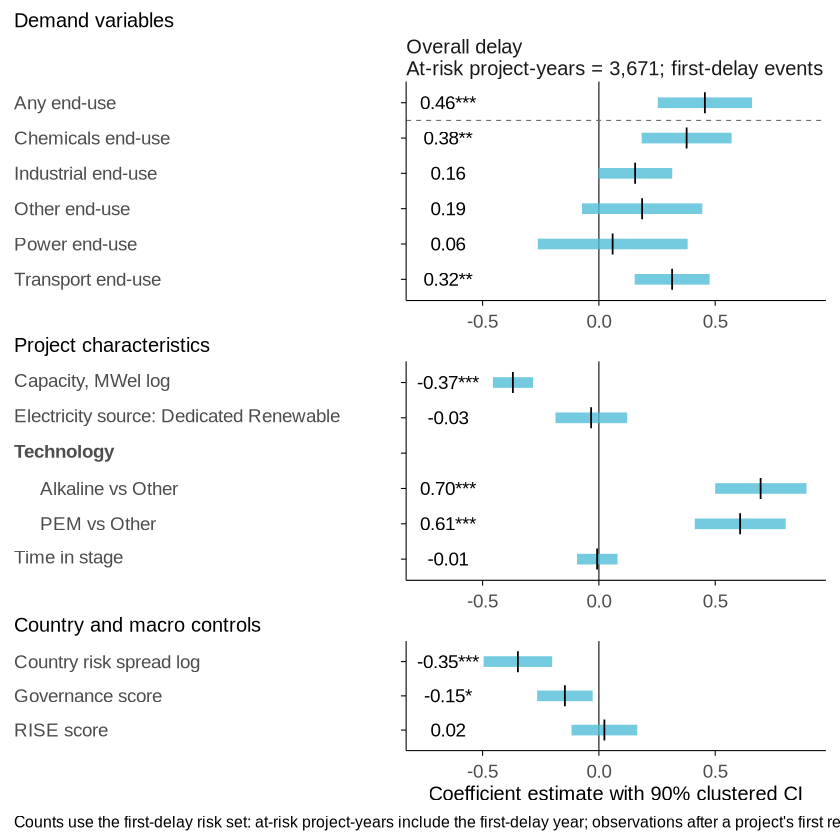

In [9]:
# ==============================================================================
# Create, display, and save delay charts
# ==============================================================================


# ------------------------------------------------------------------------------
# Overall first-delay hazard
# ------------------------------------------------------------------------------

overall_transition_lookup <- tibble::tibble(
  transition = "Overall -> Delay",
  series = "Overall",
  panel_title = "Overall delay"
)

overall_plot_data <- prepare_delay_plot_data(
  waterfall_results = delay_waterfall_results,
  transition_lookup = overall_transition_lookup,
  series_levels = "Overall"
)

p_delay_overall <- make_delay_figure(
  plot_data = overall_plot_data,
  series_colours = overall_cols,
  legend_title = NULL,
  show_legend = FALSE
)

print(
  p_delay_overall
)

ggplot2::ggsave(
  filename = "figure_delay.pdf",
  plot = p_delay_overall,
  width = 8.27,
  height = 9.5,
  units = "in",
  device = grDevices::cairo_pdf
)

utils::write.csv(
  overall_plot_data,
  "figure_delay_source_data.csv",
  row.names = FALSE
)


## Supplementary Figure S7: Delays by stage

This figure uses separate Concept, Feasibility stage and FID/construction estimations of the first-delay hazard. The first-delay risk set is constructed once across each project history and then restricted by origin stage; the event is not reset on entry into a later stage. The pooled model remains the main delay figure. The grouped-end-use and any-end-use specifications, duration control, year fixed effects and 90% project-clustered confidence intervals match the primary model architecture.

Output: `figure_S7_delays_by_stage.pdf` and `figure_S7_delays_by_stage_source_data.csv`.


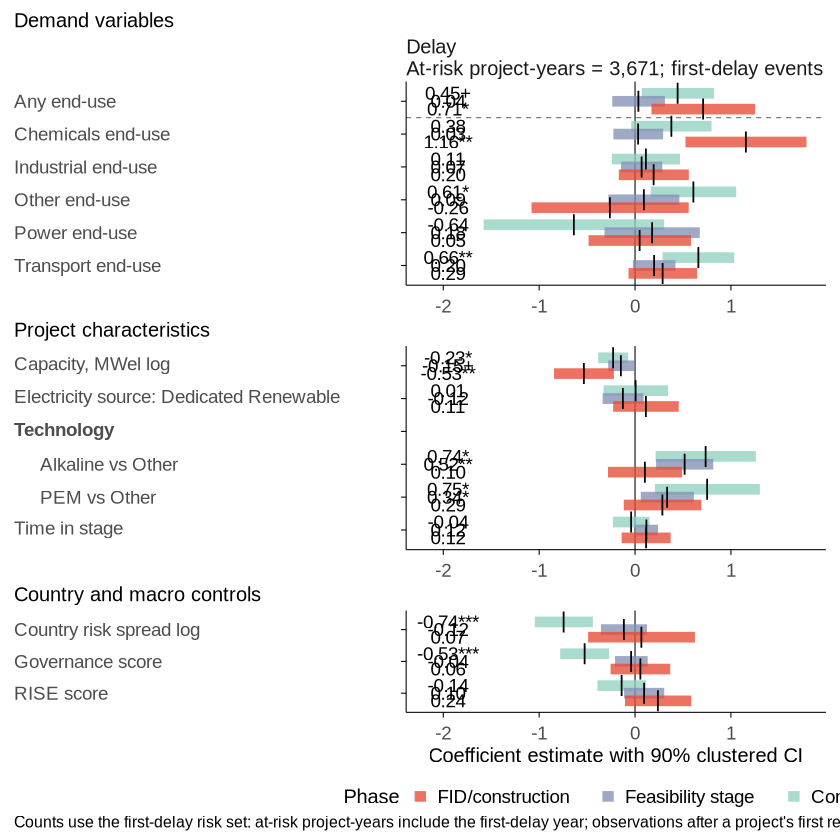

In [10]:
# ------------------------------------------------------------------------------
# Stage-specific first-delay hazards
# ------------------------------------------------------------------------------

stage_transition_lookup <- tibble::tibble(
  transition = c(
    "Concept -> Delay",
    "Feasibility -> Delay",
    "FID -> Delay"
  ),
  series = c(
    "Concept",
    "Feasibility stage",
    "FID/construction"
  ),
  panel_title = "Delay"
)

# S6 must have genuinely separate estimates for all three stages and both
# end-use specifications used in the chart. Do not export an incomplete S6.
required_s6_models <- c("Core + macro controls + year FE",
                        "Core + macro controls + year FE + any enduse")
for (stage_transition in stage_transition_lookup$transition) {
  spec <- model_specs[[stage_transition]]
  expected_stage <- match(stage_transition, stage_transition_lookup$transition)
  stopifnot(length(unique(spec$data$prev_state_numeric)) == 1L,
            all(spec$data$prev_state_numeric == expected_stage))
  for (model_name in required_s6_models) {
    model_obj <- delay_waterfall_results$models[[stage_transition]][[model_name]]
    if (is.null(model_obj) || is.null(model_obj$model)) {
      stop(paste("Cannot create complete S6; missing stage model:", stage_transition, model_name))
    }
    if ("prev_state_numeric" %in% all.vars(stats::formula(model_obj$model))) {
      stop("S6 must use separate stage estimates without pooled stage fixed effects.")
    }
  }
}

stage_plot_data <- prepare_delay_plot_data(
  waterfall_results = delay_waterfall_results,
  transition_lookup = stage_transition_lookup,
  series_levels = phase_levels
)

p_delay_stage <- make_delay_figure(
  plot_data = stage_plot_data,
  series_colours = phase_cols,
  legend_title = "Phase",
  show_legend = TRUE
)

print(
  p_delay_stage
)

ggplot2::ggsave(
  filename = "figure_S7_delays_by_stage.pdf",
  plot = p_delay_stage,
  width = 8.27,
  height = 13.5,
  units = "in",
  device = grDevices::cairo_pdf
)

utils::write.csv(
  stage_plot_data,
  "figure_S7_delays_by_stage_source_data.csv",
  row.names = FALSE
)

saveRDS(
  list(
    overall = p_delay_overall,
    stage_specific = p_delay_stage
  ),
  "delay_plot_objects.rds"
)


## Interpretation and reproducibility notes

- `first_delay_event` is absorbing: each project can contribute at most one event. Figure counts therefore distinguish at-risk project-years from first-delay events; project-years after the first recorded delay are excluded.
- The pooled model combines project-years across stages and omits stage indicators while including `prev_time_in_status` (time in stage).
- Supplementary Figure S7 reports separately estimated stage-specific models, rather than a pooled stage-fixed-effects model.
- Stage-specific models restrict the first-delay risk set to Concept, Feasibility stage, or FID/construction observations.
- The third waterfall specification supplies the specific end-use coefficients, and the fourth supplies the `any_enduse` coefficient.
- Region coefficients and year fixed effects are included in the models but omitted from the coefficient charts.
- Confidence intervals in the charts are 90% project-clustered intervals.
- Human-readable effect sizes use the main grouped-end-use specification for each overall or stage-specific delay model; capacity is reported for a doubling from the sample median and country risk for the 25th-to-75th percentile contrast (with a median-doubling backup).
